### TODO
- Construir o output da CNN
- Artigos:
  - ZANG202026
    - Os autores usam a saida dense da CNN e a Saida dense da LSTM como inputs de uma rede fully connected (outra dense).
  - RaiAmit
    - Os autores usam o output da CNN (da MaxPooling, não da Dense) como input da BiLSTM
  - Rajaprasad2023
    - Os aturoes usam o output da CNN (da MaxPooling, não da Dense) como input da BiLSTM
  - Rajagukguk2020
    - Os autores usam o output dense da CNN como input da LSTM
  - KUMARI2021117061
    - Os autores utilizam o output não-dense da LSTM e, juntamente com dados climaticos, inputam isso na CNN.
   
  - Axiomatic Attribution for Deep Networks

    - 🧠 Autores: Mukund Sundararajan, Ankur Taly, Qiqi Yan

    - 🏢 Publicado pelo Google

    - 📅 Ano: 2017

    - 🔗 Link para o paper no arXiv: https://arxiv.org/abs/1703.01365

### Imports

In [579]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv1D, Conv2D, Flatten, GlobalAveragePooling1D, LSTM, Dense, Concatenate, MaxPooling1D, MaxPooling2D
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

In [7]:
%run UtilsNew.ipynb

### Load and filter data

In [137]:
raw_anual_df = pd.read_csv("data/minas_gerais_bh.csv", sep=";")
anual_df = pre_processing(raw_anual_df)

anual_df["hora"] = anual_df["data_hora"].dt.hour
anual_df = filter_between(anual_df, "hora", 7, 18)

janela_tempo = 11

### Functions

In [574]:
def select_and_normalize_minmax(anual_df, list_cols):
    df = anual_df[list_cols]
    
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    
    return df_scaled.fillna(df_scaled.mean())

def select_and_normalize_divided(anual_df, list_cols):

    def divided_by_1000(n):
        return n/1000
        
    df = anual_df[list_cols]
    
    df_scaled = df.apply(divided_by_1000)
    
    return df_scaled.fillna(df_scaled.mean())


def criar_modelo_cnn2d_lstm(janela_tempo, n_features):
    # 🔹 CNN 2D
    input_clima = Input(shape=(n_features, janela_tempo, 1), name="input_clima")
    
    x_cnn = Conv2D(filters=64, kernel_size=(2, 3), activation='relu', padding='same')(input_clima)
    x_cnn = BatchNormalization()(x_cnn)
    
    x_cnn = Conv2D(filters=32, kernel_size=(2, 3), activation='relu', padding='same')(x_cnn)
    x_cnn = BatchNormalization()(x_cnn)

    x_cnn = MaxPooling2D(pool_size=(2, 2))(x_cnn)

    x_cnn = Conv2D(filters=16, kernel_size=(2, 2), activation='relu', padding='same')(x_cnn)
    x_cnn = BatchNormalization()(x_cnn)

    x_cnn = Flatten()(x_cnn)
    x_cnn = Dense(32, activation='relu')(x_cnn)
    x_cnn = BatchNormalization()(x_cnn)

    # 🔸 LSTM
    input_rad = Input(shape=(janela_tempo, 1), name="input_radiacao")
    x_lstm = LSTM(64, return_sequences=True)(input_rad)
    x_lstm = LSTM(32)(x_lstm)
    x_lstm = Dense(32, activation='relu')(x_lstm)
    x_lstm = BatchNormalization()(x_lstm)

    # 🔗 Concatenar CNN + LSTM
    x = Concatenate()([x_cnn, x_lstm])

    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dense(32, activation='relu')(x)

    output = Dense(1, name="saida", activation='linear')(x)

    # 🏗️ Modelo final
    model = Model(inputs=[input_clima, input_rad], outputs=output)
    model.compile(optimizer='adam', loss='mse')

    return model


def create_model_2(n_features):
    # CNN
    input_clima = Input(shape=(janela_tempo, n_features), name="input_clima")
    x_cnn = Conv1D(filters=64, kernel_size=3, activation='relu')(input_clima)
    x_cnn = BatchNormalization()(x_cnn)
    x_cnn = Conv1D(filters=32, kernel_size=3, activation='relu')(x_cnn)
    x_cnn = BatchNormalization()(x_cnn)
    x_cnn = GlobalAveragePooling1D()(x_cnn)
    x_cnn = Dense(32, activation='relu')(x_cnn)
    x_cnn = BatchNormalization()(x_cnn)

    # LSTM
    input_rad = Input(shape=(janela_tempo, 1), name="input_radiacao")
    x_lstm = LSTM(64, return_sequences=True)(input_rad)
    x_lstm = LSTM(32)(x_lstm)
    x_lstm = Dense(32, activation='relu')(x_lstm)
    x_lstm = BatchNormalization()(x_lstm)

    # Join models
    x = Concatenate()([x_cnn, x_lstm])
    # x = Dense(128, activation='relu')(x)
    # x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, name="saida", activation='linear')(x)
    
    model = Model(inputs=[input_clima, input_rad], outputs=output)
    model.compile(optimizer='adam', loss='mse')

    return model


def create_model_1(n_features):
    # CNN
    input_clima = Input(shape=(janela_tempo, n_features), name="input_clima")
    x_cnn = Conv1D(filters=64, kernel_size=3, activation='relu')(input_clima)
    x_cnn = BatchNormalization()(x_cnn)
    x_cnn = Conv1D(filters=32, kernel_size=3, activation='relu')(x_cnn)
    x_cnn = GlobalAveragePooling1D()(x_cnn)

    # LSTM
    input_rad = Input(shape=(janela_tempo, 1), name="input_radiacao")
    x_lstm = LSTM(64, return_sequences=True)(input_rad)
    x_lstm = LSTM(32)(x_lstm)

    # Join models
    x = Concatenate()([x_cnn, x_lstm])
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, name="saida", activation='linear')(x)
    
    model = Model(inputs=[input_clima, input_rad], outputs=output)
    model.compile(optimizer='adam', loss='mse')

    return model


def training_model(modelo, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val):
    modelo.fit(
        x={"input_clima": Xc_train, "input_radiacao": Xr_train},
        y=y_train,
        validation_data=(
            {"input_clima": Xc_val, "input_radiacao": Xr_val},
            y_val
        ),
        epochs=100,
        batch_size=32,
        verbose=0
    )

def criar_janelas_conv2d(df_input, df_target, janela=12, horizonte=1):
    X_cnn, X_lstm, y = [], [], []
    
    for i in range(len(df_input) - janela - horizonte + 1):
        # 🔹 Dados para CNN — formato (n_features, janela, 1)
        dados_cnn = df_input.iloc[i:i+janela].values.T  # Transpõe para (n_features, janela)
        dados_cnn = dados_cnn.reshape(dados_cnn.shape[0], dados_cnn.shape[1], 1)  # (n_features, janela, 1)
        
        # 🔹 Dados para LSTM — formato (janela, 1)
        dados_lstm = df_target.iloc[i:i+janela].values.reshape(-1, 1)
        
        # 🔹 Target — valor no horizonte futuro
        target = df_target.iloc[i+janela+horizonte-1]
        
        # 🔸 Append
        X_cnn.append(dados_cnn)
        X_lstm.append(dados_lstm)
        y.append(target)
    
    return np.array(X_cnn), np.array(X_lstm), np.array(y)
    
    
def criar_janelas(df_inpupt, df_target, janela=12, horizonte=1):
    X_clima, X_rad, y = [], [], []
    for i in range(len(df) - janela - horizonte + 1):
        dados_cnn = df_inpupt.iloc[i:i+janela].values
        dados_lstm = df_target.iloc[i:i+janela].values
        target = df_target.iloc[i+janela+horizonte-1]
        
        X_clima.append(dados_cnn)
        X_rad.append(dados_lstm)
        y.append(target)
        
    return np.array(X_clima), np.array(X_rad), np.array(y)

def plot_results(pred, real, period):
    set_plot_size(12, 6)
    
    pred = pred.reshape(pred.shape[0])
    
    df_pred = pd.DataFrame(data=pred, index=period, columns=["predicted"])
    df_real = pd.DataFrame(data=real, index=period, columns=["real"])
    
    sns.lineplot(df_pred, palette=["red"], ci=None)
    sns.lineplot(df_real, palette=["blue"], ci=None)

def get_feature_importance(X_train, Y_train, cols):

    time_steps = 12
    n_features = 16

    model = Sequential([
        Input(shape=(n_features, 1)),
        Conv1D(32, kernel_size=2, activation='relu'),
        Conv1D(16, kernel_size=2, activation='relu'),
        GlobalAveragePooling1D(),
        Dense(1, activation='linear')  # Para regressão
    ])
        
    model.compile(optimizer='adam', loss='mse')
    
    model.fit(X_train, Y_train, epochs=10, verbose=0)
    
    X_sample = X_train[0:1]
    
    attributions = integrated_gradients(model, X_sample, m_steps=100)

    
    d = {"feature": cols, "value": attributions}
    
    local_df = pd.DataFrame(data=d)
    plt.xticks(rotation=90)
    sns.barplot(local_df, x="feature", y="value")


def integrated_gradients(model,
                          input_tensor,
                          target_class_idx=None,
                          baseline=None,
                          m_steps=100):
    """
    Compute Integrated Gradients for a Keras/TensorFlow model.
    """
    if baseline is None:
        baseline = np.zeros_like(input_tensor).astype(np.float32)

    input_tensor = input_tensor.astype(np.float32)
    baseline = baseline.astype(np.float32)

    interpolated_inputs = [
        baseline + (float(alpha) / m_steps) * (input_tensor - baseline)
        for alpha in range(0, m_steps + 1)
    ]
    interpolated_inputs = tf.convert_to_tensor(np.concatenate(interpolated_inputs, axis=0))

    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        preds = model(interpolated_inputs)

        if target_class_idx is not None:
            outputs = preds[:, target_class_idx]
        else:
            outputs = tf.reduce_sum(preds, axis=1)  # Regressão

    grads = tape.gradient(outputs, interpolated_inputs)

    avg_grads = tf.reduce_mean(grads[:-1], axis=0)  # Exclui último ponto

    integrated_grads = (input_tensor - baseline) * avg_grads.numpy()

    return integrated_grads.squeeze()

def get_metrics(test_pred, y_val):
    mse = mean_squared_error(test_pred.reshape(test_pred.shape[0]), y_val)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(test_pred.reshape(test_pred.shape[0]), y_val)
    r2 = r2_score(test_pred.reshape(test_pred.shape[0]), y_val)
    
    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R2 Score: ", r2)

# Test with best 3 columns

In [575]:
list_cols = ["pto_orvalho_min_c", "umi_min_perc", "pressao_min_hpa", "radiacao"]
df_norm = select_and_normalize_divided(anual_df, list_cols)
# df_inupt = df_norm.drop("radiacao", axis=1)
df_inupt = df_norm
df_target = df_norm[["radiacao"]]

In [608]:
X_clima, X_rad, y = criar_janelas_conv2d(df_inupt, df_target, janela=janela_tempo, horizonte=1)
Xc_train, Xc_val, Xr_train, Xr_val, y_train, y_val = train_test_split(X_clima, X_rad, y, test_size=0.3, random_state=42, shuffle=False)

In [593]:
model = criar_modelo_cnn2d_lstm(janela_tempo, df_inupt.shape[1])
training_model(model, Xc_train, Xr_train, y_train, Xc_val, Xr_val, y_val)

In [594]:
train_pred = model.predict(x={"input_clima": Xc_train, "input_radiacao": Xr_train})
test_pred = model.predict(x={"input_clima": Xc_val, "input_radiacao": Xr_val})

42/42 [==============================] - 0s 5ms/step


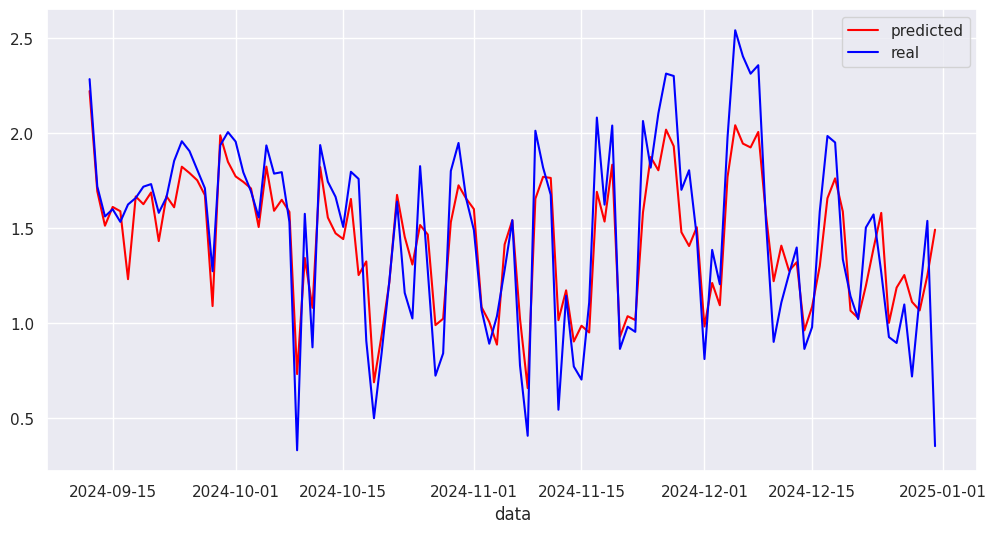

In [595]:
period = anual_df[train_pred.shape[0]:]['data'].iloc[:test_pred.shape[0]]
plot_results(test_pred.reshape(test_pred.shape[0]), y_val, period)

In [596]:
get_metrics(test_pred, y_val)

MSE:  0.2877274357074984
RMSE:  0.5364023077015034
MAE:  0.3933778289533296
R2 Score:  0.6353903916279329


In [610]:
#  Teste 1: modelo concatenando saidas não-dense, com Conv1D
#  Teste 2: modelo concatenando saidas não-dense, com Conv2D
#  Teste 3: modelo concatenando saidas não-dense, com Conv2D em reshape

#  Teste 4: modelo concatenando saidas dense, com Conv1D
#  Teste 5: modelo concatenando saidas dense, com Conv2D
#  Teste 6: modelo concatenando saidas dense, com Conv2D em reshape